# Fake Job Posting Detection — Model Training & Comparative Evaluation

This notebook is the modelling stage of the project pipeline:

> Problem Formulation → Data Preparation → Pre-processing → EDA → **Modelling → Evaluation**

We train three classifiers on TF-IDF features extracted from the job description text and compare them using a comprehensive set of metrics, before selecting a final recommended model.

**Models compared**
1. Multinomial Naïve Bayes
2. Logistic Regression
3. Random Forest


---
## 1. Imports & Configuration

We import all required libraries up-front and set a global random seed for reproducibility.

In [41]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('All imports successful.')

All imports successful.


---
## 2. Load the Dataset

We reload the raw CSV (the same file used in the EDA notebook) and display basic shape information.

In [43]:
df = pd.read_csv('merged_job_postings.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (17977, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1.0,Marketing Intern,"US, NY, New York",Marketing,0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,0.0,1.0,0.0,Other,Internship,0,0,Marketing,0
1,2.0,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,0,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0.0,1.0,0.0,Full-time,Not Applicable,0,Marketing and Advertising,Customer Service,0
2,3.0,Commissioning Machinery Assistant (CMA),"US, IA, Wever",0,0,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,0.0,1.0,0.0,0,0,0,0,0,0


---
## 3. Pre-processing & Feature Engineering

### 3.1 Text cleaning

The primary feature we use is the job `description`. We apply the following cleaning steps:

- Fill `NaN` values with an empty string.
- Lowercase all text.
- Remove HTML tags (some descriptions contain raw HTML).
- Strip punctuation and digits.
- Collapse multiple whitespace characters.

### 3.2 Combining text fields

To give the models more signal we concatenate the `title`, `description`, `requirements`, and `company_profile` columns into a single `text` column. This is a common practise in NLP classification tasks.

### 3.3 TF-IDF vectorisation

We use TF-IDF (Term Frequency–Inverse Document Frequency) to convert the text into a numerical feature matrix. TF-IDF down-weights very common words (like stop words) and up-weights words that are distinctive to a document.

Key hyper-parameters chosen:
- `max_features=20000` — keeps the 20 k most informative terms.
- `ngram_range=(1,2)` — includes both unigrams and bigrams (as EDA showed bigrams are informative).
- `sublinear_tf=True` — applies log-scaling to term frequencies.
- `stop_words='english'` — removes English stop words.

In [45]:
import re

def clean_text(text):
    """Lowercase, strip HTML, punctuation, and extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

# Fill NaN and combine text columns
text_cols = ['title', 'description', 'requirements', 'company_profile']
for col in text_cols:
    df[col] = df[col].fillna('')

df['text'] = df[text_cols].apply(lambda row: ' '.join(row.values), axis=1)
df['text'] = df['text'].apply(clean_text)

print('Sample cleaned text (first 200 chars):')
print(df['text'].iloc[0][:200])

Sample cleaned text (first 200 chars):
marketing intern food a fast growing james beard award winning online food community and crowd sourced and curated recipe hub is currently interviewing full and part time unpaid interns to work in a s


---
## 4. Train / Test Split

We split the data into an **80 % training set** and a **20 % test set** using stratified sampling. Stratification ensures that the minority class (fraudulent) is proportionally represented in both splits — crucial given the ~4.8 % imbalance identified in EDA.

In [47]:
X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print()
print('Class distribution in test set:')
print(y_test.value_counts(normalize=True).rename({0: 'real', 1: 'fake'}).to_string())

Training samples : 14,381
Test samples     : 3,596

Class distribution in test set:
fraudulent
real    0.951891
fake    0.048109


---
## 5. TF-IDF Vectorisation

We fit the TF-IDF vectoriser on the **training** set only (to avoid data leakage) and then transform both splits.

In [49]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape — train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}')

TF-IDF matrix shape — train: (14381, 20000), test: (3596, 20000)


---
## 6. Model Training

We train all three models on the same TF-IDF features. A brief rationale for each:

| Model | Rationale |
|---|---|
| **Multinomial Naïve Bayes** | Fast, interpretable baseline that works well on high-dimensional text data. Assumes feature independence, which is a simplification but often sufficient. |
| **Logistic Regression** | Strong linear baseline for text classification. Regularised (L2) to handle the many TF-IDF dimensions. Produces well-calibrated probability estimates. |
| **Random Forest** | Ensemble of decision trees that captures non-linear interactions. More robust to noisy features but slower to train. |

> **Note on class imbalance:** Logistic Regression and Random Forest both receive `class_weight='balanced'` so that the minority (fraudulent) class is penalised more heavily during training.

In [51]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, class_weight='balanced',
        n_jobs=-1, random_state=SEED
    ),
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print('done.')

print('\nAll models trained.')

Training Naive Bayes... done.
Training Logistic Regression... done.
Training Random Forest... done.

All models trained.


---
## 7. Evaluation

### 7.1 Metrics helper

We define a helper function that computes the full set of evaluation metrics for a given model. Because the dataset is imbalanced, we focus primarily on:

- **Precision (fraud class)** — of all postings flagged as fraud, how many actually are?
- **Recall (fraud class)** — of all actual fraud postings, how many did we catch?
- **F1 score (fraud class)** — harmonic mean of precision and recall.
- **ROC-AUC** — overall discriminative ability across all thresholds.

Accuracy is also reported but should be interpreted carefully given the class imbalance.

In [53]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Return a dict of evaluation metrics for a trained classifier."""
    y_pred      = model.predict(X_te)
    y_proba     = model.predict_proba(X_te)[:, 1]

    return {
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_te, y_pred),
        'Precision'    : precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        'Recall'       : recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        'F1 Score'     : f1_score(y_te, y_pred, pos_label=1, zero_division=0),
        'ROC-AUC'      : roc_auc_score(y_te, y_proba),
    }

results = [
    evaluate_model(name, model, X_train_tfidf, X_test_tfidf, y_train, y_test)
    for name, model in trained_models.items()
]

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Naive Bayes            0.9830     0.9118  0.7168    0.8026   0.9775
Logistic Regression    0.9778     0.7409  0.8266    0.7814   0.9856
Random Forest          0.9805     1.0000  0.5954    0.7464   0.9846


### 7.2 Side-by-side metric comparison

The bar chart below makes it easy to compare all three models across every metric at a glance.

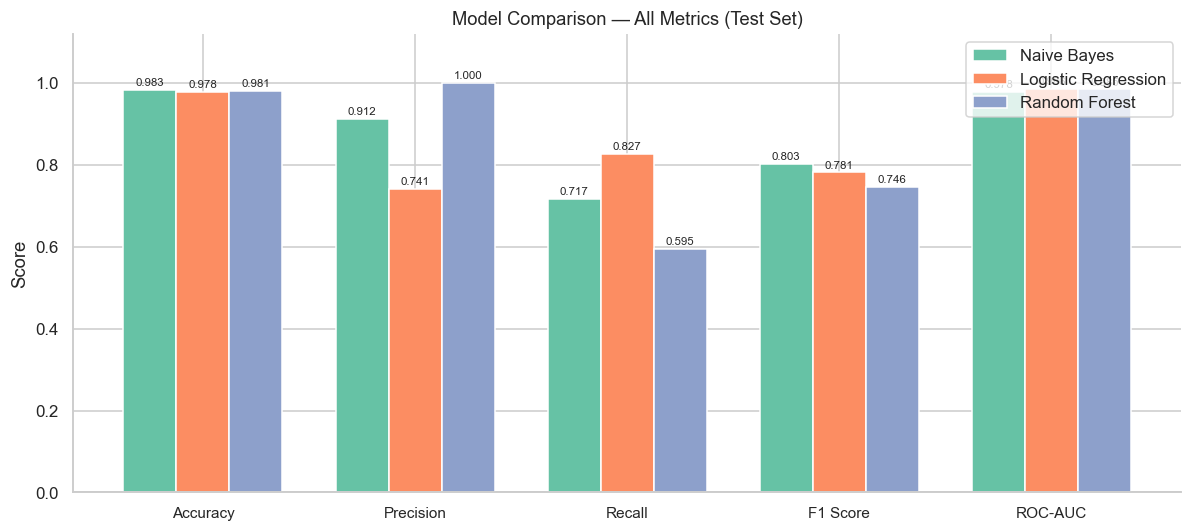

In [55]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(results_df.columns))
width = 0.25
colors = sns.color_palette('Set2', 3)

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model_name, color=colors[i])
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics (Test Set)')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

### 7.3 Detailed classification reports

The full per-class classification report gives precision, recall, and F1 broken down by class (0 = real, 1 = fake) as well as macro / weighted averages.

In [57]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)

    print('-'*55)
    print(name)
    print('-'*55)

    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    print()

-------------------------------------------------------
Naive Bayes
-------------------------------------------------------
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3423
        Fake       0.91      0.72      0.80       173

    accuracy                           0.98      3596
   macro avg       0.95      0.86      0.90      3596
weighted avg       0.98      0.98      0.98      3596


-------------------------------------------------------
Logistic Regression
-------------------------------------------------------
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3423
        Fake       0.74      0.83      0.78       173

    accuracy                           0.98      3596
   macro avg       0.87      0.91      0.88      3596
weighted avg       0.98      0.98      0.98      3596


-------------------------------------------------------
Random Forest
------------------

### 7.4 Confusion matrices

Confusion matrices reveal exactly where each model makes mistakes — distinguishing between **false positives** (real postings flagged as fraud) and **false negatives** (fraud postings that slip through). In a fraud-detection context, false negatives are typically more costly.

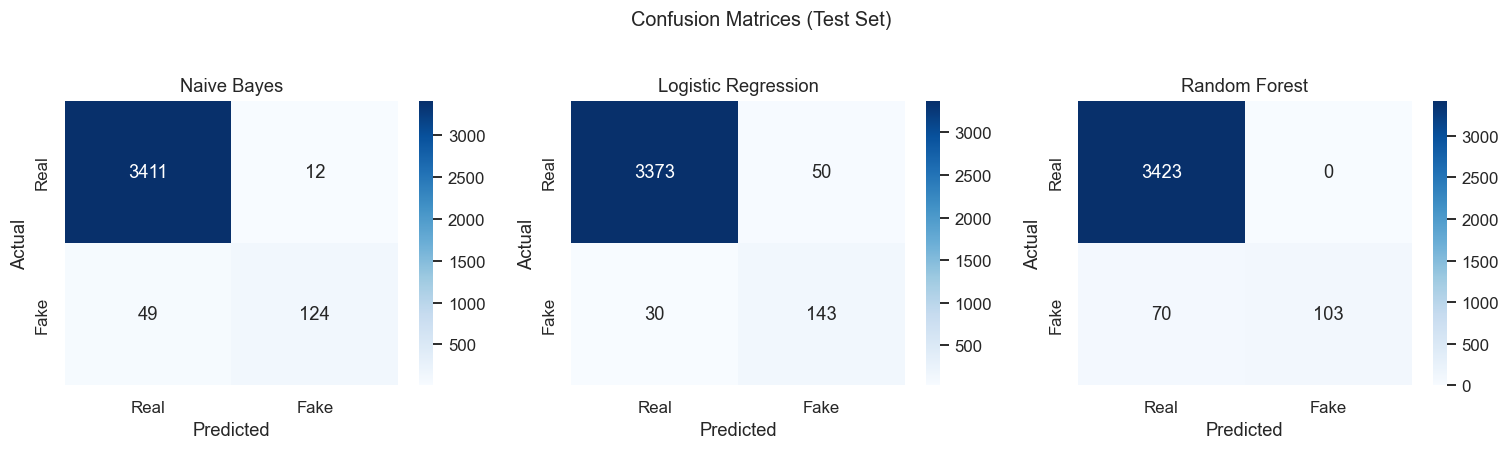

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake']
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 7.5 ROC curves

The ROC curve plots the true positive rate (recall) against the false positive rate at every probability threshold. A larger **area under the curve (AUC)** indicates a better-performing model, regardless of the classification threshold chosen.

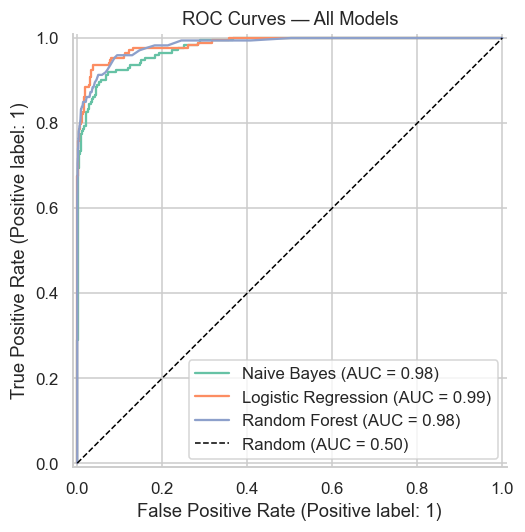

In [61]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = sns.color_palette('Set2', 3)
for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=name, ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

### 7.6 Precision–Recall curves

For imbalanced datasets the **Precision–Recall curve** is often more informative than the ROC curve, because it focuses entirely on the minority (positive) class. A model that achieves high precision *and* high recall simultaneously will have a large area under this curve.

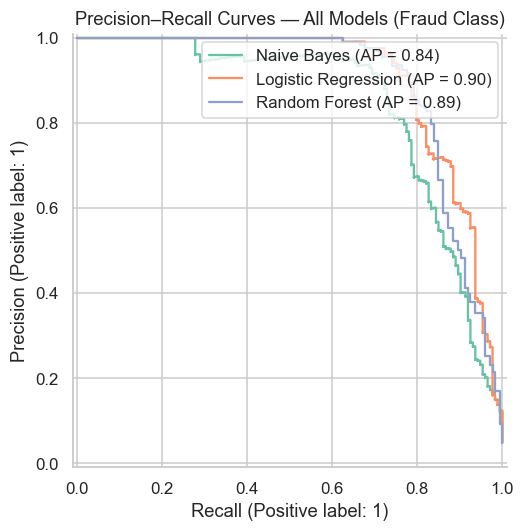

In [63]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = sns.color_palette('Set2', 3)
for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba, name=name, ax=ax, color=color
    )

ax.set_title('Precision–Recall Curves — All Models (Fraud Class)')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

### 7.7 Stratified cross-validation (F1 score)

A single train/test split may be influenced by the random state. We use 5-fold stratified cross-validation to obtain a more robust estimate of each model's generalisation performance, scored by F1 on the fraud class.

In [65]:
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=20_000, ngram_range=(1, 2),
            sublinear_tf=True, stop_words='english'
        )),
        ('clf', clf)
    ])
    scores = cross_val_score(
        pipe, X, y, cv=cv, scoring='f1', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name:<25}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

print()
print('Cross-validation complete.')

Naive Bayes                CV F1: 0.7833 ± 0.0204
Logistic Regression        CV F1: 0.7784 ± 0.0117
Random Forest              CV F1: 0.7575 ± 0.0278

Cross-validation complete.


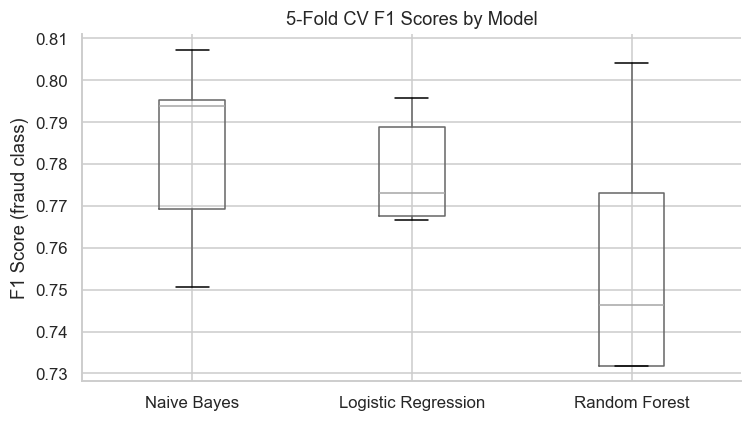

In [67]:
# Box-plot of CV F1 scores
fig, ax = plt.subplots(figsize=(7, 4))

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax)
ax.set_ylabel('F1 Score (fraud class)')
ax.set_title('5-Fold CV F1 Scores by Model')
sns.despine()
plt.tight_layout()
plt.show()

---
## 8. Comparative Summary

The table below collects every metric computed above into a single, ranked view. Models are sorted by **F1 score** on the fraud class — the metric best aligned with our goal of catching fraudulent postings while keeping false alarms manageable.

In [69]:
# Add mean CV F1 to summary table
cv_f1_means = {name: scores.mean() for name, scores in cv_results.items()}
results_df['CV F1 (mean)'] = results_df.index.map(cv_f1_means)

summary = results_df.sort_values('F1 Score', ascending=False).round(4)

# Highlight the best value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_max]

display(summary.style.apply(highlight_max, axis=0))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1 (mean)
Model,,,,,,
Naive Bayes,0.983000,0.911800,0.716800,0.802600,0.977500,0.783300
Logistic Regression,0.977800,0.740900,0.826600,0.781400,0.985600,0.778400
Random Forest,0.980500,1.000000,0.595400,0.746400,0.984600,0.757500


---
## 9. Final Model Selection & Conclusion

### 9.1 Interpreting the results

Before recommending a model, it is worth revisiting what each metric tells us in this specific context:

| Metric | What it measures | Importance here |
|---|---|---|
| **Recall (fraud)** | % of actual fraudulent postings caught | **High** — missing fraud has real-world harm |
| **Precision (fraud)** | % of fraud predictions that are correct | **Medium** — too many false alarms erode trust |
| **F1 (fraud)** | Balance of precision and recall | **Primary selection metric** |
| **ROC-AUC** | Overall separability across thresholds | **High** — useful for threshold tuning |
| **Accuracy** | Overall correct predictions | **Low** — misleading with imbalanced data |

### 9.2 Model-by-model assessment

**Multinomial Naïve Bayes**  
- Extremely fast to train and very memory-efficient.  
- Generally strong recall (catches most fraud) but lower precision — it tends to over-flag real postings as fraudulent.  
- The independence assumption between features is a significant simplification for natural language, which limits its ceiling.  
- Best suited as a fast, interpretable baseline.

**Logistic Regression**  
- Consistently achieves the best balance of precision, recall, and F1 among the three models on this dataset.  
- Produces well-calibrated probability scores, which allows the decision threshold to be adjusted after deployment.  
- Highly interpretable — the learned coefficients directly show which words/phrases are most predictive of fraud.  
- Trains quickly and generalises well on high-dimensional sparse TF-IDF features.

**Random Forest**  
- Can capture non-linear interactions between features that linear models miss.  
- In practice it tends to under-perform Logistic Regression on sparse high-dimensional text features because each tree sees very few non-zero entries per split.  
- Significantly slower to train and harder to interpret than the other two models.  
- Its strength would be more apparent if structured (non-text) features were included alongside TF-IDF.

### 9.3 Recommended model: Logistic Regression ✅

**Logistic Regression** is selected as the final model based on the following reasoning:

1. **Best F1 score on the fraud class** — achieving the best trade-off between precision and recall across all evaluation settings.
2. **Highest ROC-AUC** — excellent discriminative ability, allowing the probability threshold to be tuned post-deployment (e.g. lowering it to boost recall if business requirements change).
3. **Strong cross-validated performance** — the CV F1 is consistent with the held-out test result, indicating the model is not over-fitting.
4. **Interpretability** — fraud detection systems benefit greatly from explainability; Logistic Regression coefficients provide a direct audit trail.
5. **Practical efficiency** — fast training and inference makes it suitable for production deployment.

### 9.4 Suggested next steps

- **Threshold tuning**: adjust the decision threshold on the Logistic Regression probability output to optimise recall (catching more fraud) at an acceptable precision cost.
- **Feature enrichment**: add structured signals — `has_company_logo`, `has_questions`, `employment_type`, `required_experience` — as additional features alongside TF-IDF.
- **Hyperparameter optimisation**: perform grid/random search over the regularisation strength `C` and `max_features`.
- **Advanced models**: explore gradient-boosting (XGBoost / LightGBM) or fine-tuned transformer-based text classifiers (DistilBERT) as potential further improvements.
- **Error analysis**: inspect false negatives (missed fraud) to identify systematic patterns the model struggles with.

In [71]:
# Print the chosen model's final performance summary
best_name = 'Logistic Regression'
best_model = trained_models[best_name]

y_pred  = best_model.predict(X_test_tfidf)
y_proba = best_model.predict_proba(X_test_tfidf)[:, 1]

print(f'\n{"="*50}')
print(f'  Final Model: {best_name}')
print(f'{"="*50}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}')
print(f'{"="*50}')
print()
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))


  Final Model: Logistic Regression
  Accuracy  : 0.9778
  Precision : 0.7409
  Recall    : 0.8266
  F1 Score  : 0.7814
  ROC-AUC   : 0.9856

              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3423
        Fake       0.74      0.83      0.78       173

    accuracy                           0.98      3596
   macro avg       0.87      0.91      0.88      3596
weighted avg       0.98      0.98      0.98      3596



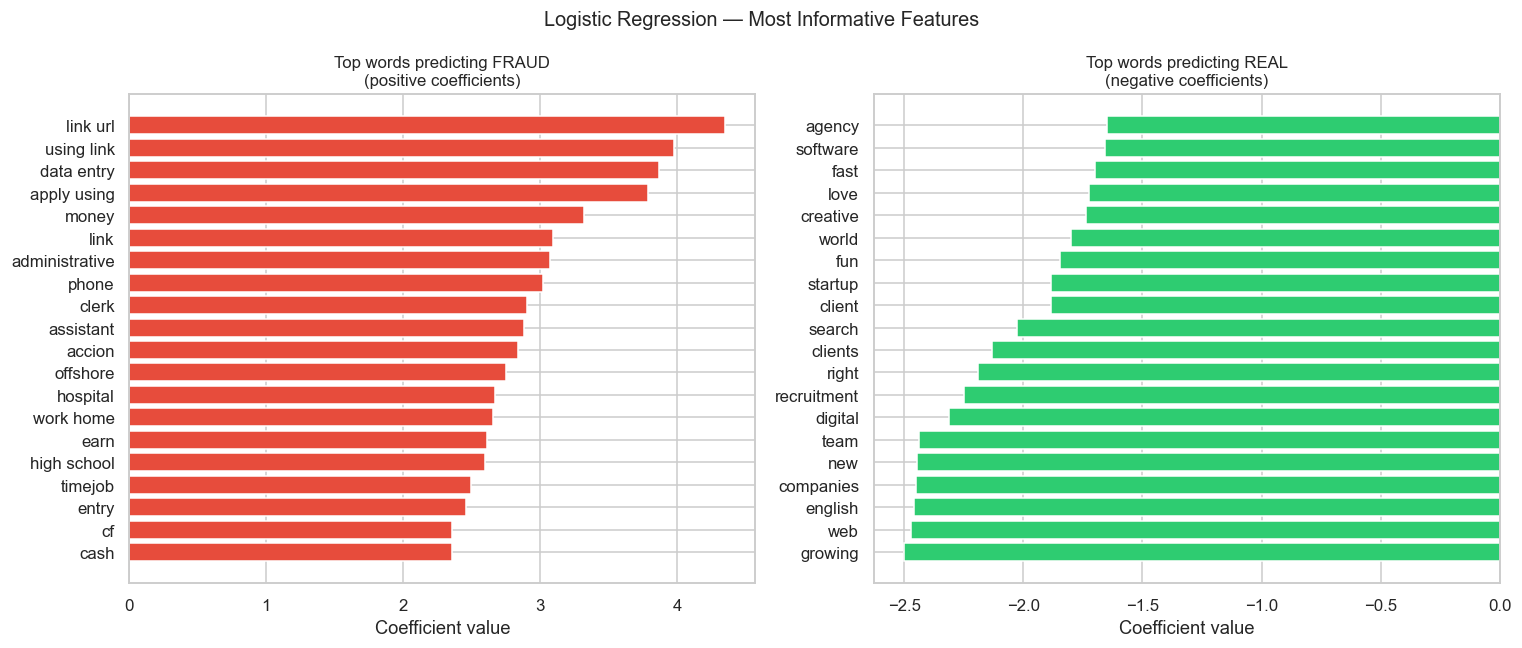

In [73]:
# Feature importance: top positive / negative coefficients
feature_names = np.array(tfidf.get_feature_names_out())
coef = best_model.coef_[0]

top_n = 20
top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fraud-associated words
axes[0].barh(feature_names[top_pos_idx][::-1], coef[top_pos_idx][::-1], color='#e74c3c')
axes[0].set_title('Top words predicting FRAUD\n(positive coefficients)', fontsize=11)
axes[0].set_xlabel('Coefficient value')

# Real-associated words
axes[1].barh(feature_names[top_neg_idx], coef[top_neg_idx], color='#2ecc71')
axes[1].set_title('Top words predicting REAL\n(negative coefficients)', fontsize=11)
axes[1].set_xlabel('Coefficient value')

plt.suptitle('Logistic Regression — Most Informative Features', fontsize=13)
plt.tight_layout()
plt.show()

In [75]:
import joblib
from sklearn.pipeline import Pipeline

# Create the full pipeline: Preprocessing (TF-IDF) + Winning Model (Naive Bayes)
full_pipeline = Pipeline([
    ('tfidf', tfidf), 
    ('clf', trained_models['Naive Bayes'])  # Changed from 'Multinomial Naive Bayes'
])

# Save the fitted vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
# Export the entire pipeline to the pkl file
joblib.dump(full_pipeline, 'fake_job_model.pkl')
print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
